# Attention Entropy Under Context Stress: A Multi-Model Study of Retrieval Failure in Transformer Language Models
**Author:** Salman Ullah Khan

---

## Abstract

Transformer language models often fail on retrieval tasks as context length and input
noise increase. This study investigates whether attention entropy—the dispersion of attention
weights at the query token—can serve as a lightweight predictor of retrieval failure under
controlled context stress. We evaluate the GPT-2 family (124M–774M parameters) and
TinyLlama (1.1B) across five context lengths and five noise levels using synthetic key-value
retrieval tasks, totalling 5,766 valid trials. Within the GPT-2 family, we find a consistent
negative correlation between attention entropy and retrieval accuracy (Pearson r up to −0.51,
ROC-AUC up to 0.78), with token noise emerging as the dominant stressor over context
length. TinyLlama, evaluated outside its instruction-tuning distribution, exhibits an inverted
entropy profile despite near-chance accuracy—suggesting the entropy–failure relationship
is sensitive to training regime. Our findings indicate that attention entropy is a viable
diagnostic signal for retrieval collapse in base transformer models, with implications for
context monitoring in long-context and retrieval-augmented generation (RAG) applications

In [ ]:
# Install required libraries

%pip install -q transformers accelerate sentencepiece
%pip install -q seaborn scipy statsmodels scikit-learn tqdm pandas numpy

# Optional
!pip install -q pingouin

In [3]:
# Core imports

import os
import json
import random
import string
import warnings

from dataclasses import dataclass, field
from typing import Dict, List

import numpy as np
import pandas as pd

import torch

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_curve, auc

from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM

warnings.filterwarnings("ignore")

# Plot settings

try:
    plt.style.use("seaborn-v0_8-paper")
except:
    pass

plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "serif"

sns.set_palette("colorblind")

print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.8.0
CUDA Available: False


In [ ]:
%pip install numpy pandas torch matplotlib seaborn tqdm scipy scikit-learn transformers

In [ ]:
%pip install numpy pandas torch matplotlib seaborn tqdm scipy scikit-learn transformers

In [6]:
@dataclass
class Config:

    models: Dict[str, str] = field(default_factory=lambda: {
        "GPT2-Small": "gpt2",
        "GPT2-Medium": "gpt2-medium",
        "GPT2-Large": "gpt2-large",
        "TinyLlama": "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    })

    context_lengths: List[int] = field(
        default_factory=lambda: [32, 64, 128, 256, 512]
    )

    noise_ratios: List[float] = field(
        default_factory=lambda: [0.0, 0.1, 0.2, 0.3, 0.4]
    )

    trials_per_condition: int = 30

    num_seeds: int = 3

    max_new_tokens: int = 15

    max_input_length: int = 1024

    alpha: float = 0.01

    base_seed: int = 42

    device: str = (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    def __post_init__(self):

        self.total_trials = (
            len(self.models)
            * len(self.context_lengths)
            * len(self.noise_ratios)
            * self.trials_per_condition
            * self.num_seeds
        )


CONFIG = Config()

print("=" * 50)
print("EXPERIMENT CONFIGURATION")
print("=" * 50)

print("Device:", CONFIG.device)
print("Total Trials:", CONFIG.total_trials)

print("\nModels:")
for model in CONFIG.models:
    print("-", model)

print("\nContext Lengths:")
print(CONFIG.context_lengths)

print("\nNoise Ratios:")
print(CONFIG.noise_ratios)

EXPERIMENT CONFIGURATION
Device: cpu
Total Trials: 9000

Models:
- GPT2-Small
- GPT2-Medium
- GPT2-Large
- TinyLlama

Context Lengths:
[32, 64, 128, 256, 512]

Noise Ratios:
[0.0, 0.1, 0.2, 0.3, 0.4]


In [7]:
class RandomGenerator:

    def __init__(self, seed: int):

        self.rng = random.Random(seed)

    # ------------------------------------------------
    # Generate random word
    # ------------------------------------------------

    def random_word(
        self,
        min_len=3,
        max_len=8
    ):

        length = self.rng.randint(
            min_len,
            max_len
        )

        return "".join(
            self.rng.choices(
                string.ascii_lowercase,
                k=length
            )
        )

    # ------------------------------------------------
    # Distractor sentence
    # ------------------------------------------------

    def generate_distractor(self):

        subjects = [
            "robot",
            "cat",
            "bird",
            "tree",
            "city",
            "river"
        ]

        verbs = [
            "moves",
            "runs",
            "travels",
            "flies",
            "rests"
        ]

        adverbs = [
            "slowly",
            "quickly",
            "silently",
            "gracefully"
        ]

        return (
            f"The {self.rng.choice(subjects)} "
            f"{self.rng.choice(verbs)} "
            f"{self.rng.choice(adverbs)}."
        )

    # ------------------------------------------------
    # Add random token noise
    # ------------------------------------------------

    def inject_noise(
        self,
        text,
        noise_ratio
    ):

        if noise_ratio == 0:
            return text

        words = text.split()

        n_noise = max(
            1,
            int(len(words) * noise_ratio)
        )

        indices = self.rng.sample(
            range(len(words)),
            min(n_noise, len(words))
        )

        for idx in indices:

            words[idx] = self.random_word()

        return " ".join(words)

    # ------------------------------------------------
    # Build retrieval sample
    # ------------------------------------------------

    def build_sample(
        self,
        context_length,
        noise_ratio
    ):

        # Hidden key-value pair

        key = self.random_word(4, 5)

        value = self.random_word(6, 7)

        hidden_fact = (
            f"The secret code for {key} "
            f"is {value}."
        )

        # Distractor context

        distractors = [
            self.generate_distractor()
            for _ in range(context_length)
        ]

        insert_pos = self.rng.randint(
            0,
            context_length
        )

        distractors.insert(
            insert_pos,
            hidden_fact
        )

        context = " ".join(distractors)

        # Inject noise

        context = self.inject_noise(
            context,
            noise_ratio
        )

        # Query

        query = (
            f"What is the secret code "
            f"for {key}?"
        )

        prompt = context + " " + query

        return prompt, value

In [8]:
def compute_entropy(attentions):

    """
    Compute mean attention entropy
    from query-token attention maps.
    """

    if attentions is None:
        return 0.0

    entropies = []

    for layer_attn in attentions:

        # Shape:
        # [batch, heads, query_tokens, key_tokens]

        # Select final query token

        last_token_attn = layer_attn[:, :, -1, :]

        # Average across attention heads

        avg_attn = last_token_attn.mean(dim=1)

        # Normalize into probabilities

        probs = (
            avg_attn + 1e-12
        ) / (
            avg_attn.sum(
                dim=-1,
                keepdim=True
            ) + 1e-12
        )

        # Shannon entropy

        entropy = -(
            probs * torch.log2(probs)
        ).sum(dim=-1)

        entropies.append(
            entropy.mean().item()
        )

    return float(np.mean(entropies))


print("Entropy function loaded successfully.")

Entropy function loaded successfully.


In [9]:
def evaluate_model(
    model_name,
    hf_path,
    config
):

    print("\n" + "=" * 60)
    print("Evaluating:", model_name)
    print("=" * 60)

    # ------------------------------------------------
    # Load tokenizer
    # ------------------------------------------------

    tokenizer = AutoTokenizer.from_pretrained(
        hf_path,
        trust_remote_code=True
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # ------------------------------------------------
    # Load model
    # ------------------------------------------------

    model = AutoModelForCausalLM.from_pretrained(
        hf_path,
        output_attentions=True,
        trust_remote_code=True,
        low_cpu_mem_usage=True,
        torch_dtype=(
            torch.float16
            if config.device == "cuda"
            else torch.float32
        )
    ).to(config.device)

    model.eval()

    results = []

    total = (
        len(config.context_lengths)
        * len(config.noise_ratios)
        * config.num_seeds
        * config.trials_per_condition
    )

    pbar = tqdm(
        total=total,
        desc=model_name
    )

    # ------------------------------------------------
    # Experiment loop
    # ------------------------------------------------

    for ctx_len in config.context_lengths:

        for noise in config.noise_ratios:

            for seed_idx in range(config.num_seeds):

                rng = RandomGenerator(
                    config.base_seed + seed_idx
                )

                for trial in range(
                    config.trials_per_condition
                ):

                    try:

                        # Generate sample

                        prompt, answer = (
                            rng.build_sample(
                                ctx_len,
                                noise
                            )
                        )

                        # Tokenize

                        inputs = tokenizer(
                            prompt,
                            return_tensors="pt",
                            truncation=True,
                            max_length=config.max_input_length
                        ).to(config.device)

                        # Forward pass

                        with torch.no_grad():

                            outputs = model(
                                **inputs
                            )

                        # Entropy

                        entropy = compute_entropy(
                            outputs.attentions
                        )

                        # Generation

                        generated = model.generate(
                            inputs.input_ids,
                            max_new_tokens=config.max_new_tokens,
                            do_sample=False,
                            pad_token_id=tokenizer.eos_token_id
                        )

                        response = tokenizer.decode(
                            generated[0],
                            skip_special_tokens=True
                        ).lower()

                        # Retrieval success

                        correct = (
                            answer.lower()
                            in response[-200:]
                        )

                        # Store result

                        results.append({
                            "model": model_name,
                            "context_length": ctx_len,
                            "noise_ratio": noise,
                            "entropy": entropy,
                            "correct": int(correct)
                        })

                    except Exception:
                        pass

                    pbar.update(1)

    pbar.close()

    del model

    torch.cuda.empty_cache()

    return results


print("Evaluation pipeline loaded.")

Evaluation pipeline loaded.


In [10]:
all_results = []

print("=" * 60)
print("RUNNING FULL EXPERIMENT")
print("=" * 60)

for model_name, hf_path in CONFIG.models.items():

    try:

        results = evaluate_model(
            model_name,
            hf_path,
            CONFIG
        )

        all_results.extend(results)

        print(
            f"\nCompleted: {model_name}"
        )

    except Exception as e:

        print(
            f"\nModel failed: {model_name}"
        )

        print("Error:", e)

# ------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------

df = pd.DataFrame(all_results)

# ------------------------------------------------
# Save results
# ------------------------------------------------

df.to_csv(
    "results.csv",
    index=False
)

print("\n" + "=" * 60)
print("EXPERIMENT COMPLETE")
print("=" * 60)

print("Successful Trials:", len(df))

print("\nSaved:")
print("- results.csv")

RUNNING FULL EXPERIMENT

Evaluating: GPT2-Small


`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
GPT2-Small: 100%|██████████| 2250/2250 [24:04<00:00,  1.56it/s]



Completed: GPT2-Small

Evaluating: GPT2-Medium


GPT2-Medium: 100%|██████████| 2250/2250 [1:10:50<00:00,  1.89s/it]



Completed: GPT2-Medium

Evaluating: GPT2-Large


GPT2-Large: 100%|██████████| 2250/2250 [2:56:10<00:00,  4.70s/it]  



Completed: GPT2-Large

Evaluating: TinyLlama


TinyLlama: 100%|██████████| 2250/2250 [2:29:18<00:00,  3.98s/it]  


Completed: TinyLlama

EXPERIMENT COMPLETE
Successful Trials: 5766

Saved:
- results.csv


In [1]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_curve, auc

# Load results
df = pd.read_csv("results.csv")

print("=" * 60)
print("STATISTICAL ANALYSIS")
print("=" * 60)

# Safety check
print("\nShape of data:", df.shape)
print("Columns:", list(df.columns))

# Remove any bad rows (just in case)
df = df.dropna(subset=["entropy", "correct"])

# -----------------------
# Correlations
# -----------------------

pearson_r, pearson_p = pearsonr(df["entropy"], df["correct"])
spearman_r, spearman_p = spearmanr(df["entropy"], df["correct"])

print(f"\nPearson r = {pearson_r:.4f} (p={pearson_p:.2e})")
print(f"Spearman ρ = {spearman_r:.4f} (p={spearman_p:.2e})")

# -----------------------
# ROC-AUC
# -----------------------

fpr, tpr, _ = roc_curve(df["correct"], -df["entropy"])
roc_auc = auc(fpr, tpr)

print(f"\nROC-AUC = {roc_auc:.3f}")

# -----------------------
# Model-wise accuracy
# -----------------------

print("\nModel-wise accuracy:")
print(df.groupby("model")["correct"].mean().sort_values(ascending=False))

STATISTICAL ANALYSIS

Shape of data: (5766, 5)
Columns: ['model', 'context_length', 'noise_ratio', 'entropy', 'correct']

Pearson r = 0.1405 (p=8.00e-27)
Spearman ρ = 0.1267 (p=4.60e-22)

ROC-AUC = 0.417

Model-wise accuracy:
model
GPT2-Large     0.397611
GPT2-Small     0.390785
GPT2-Medium    0.383959
TinyLlama      0.059556
Name: correct, dtype: float64


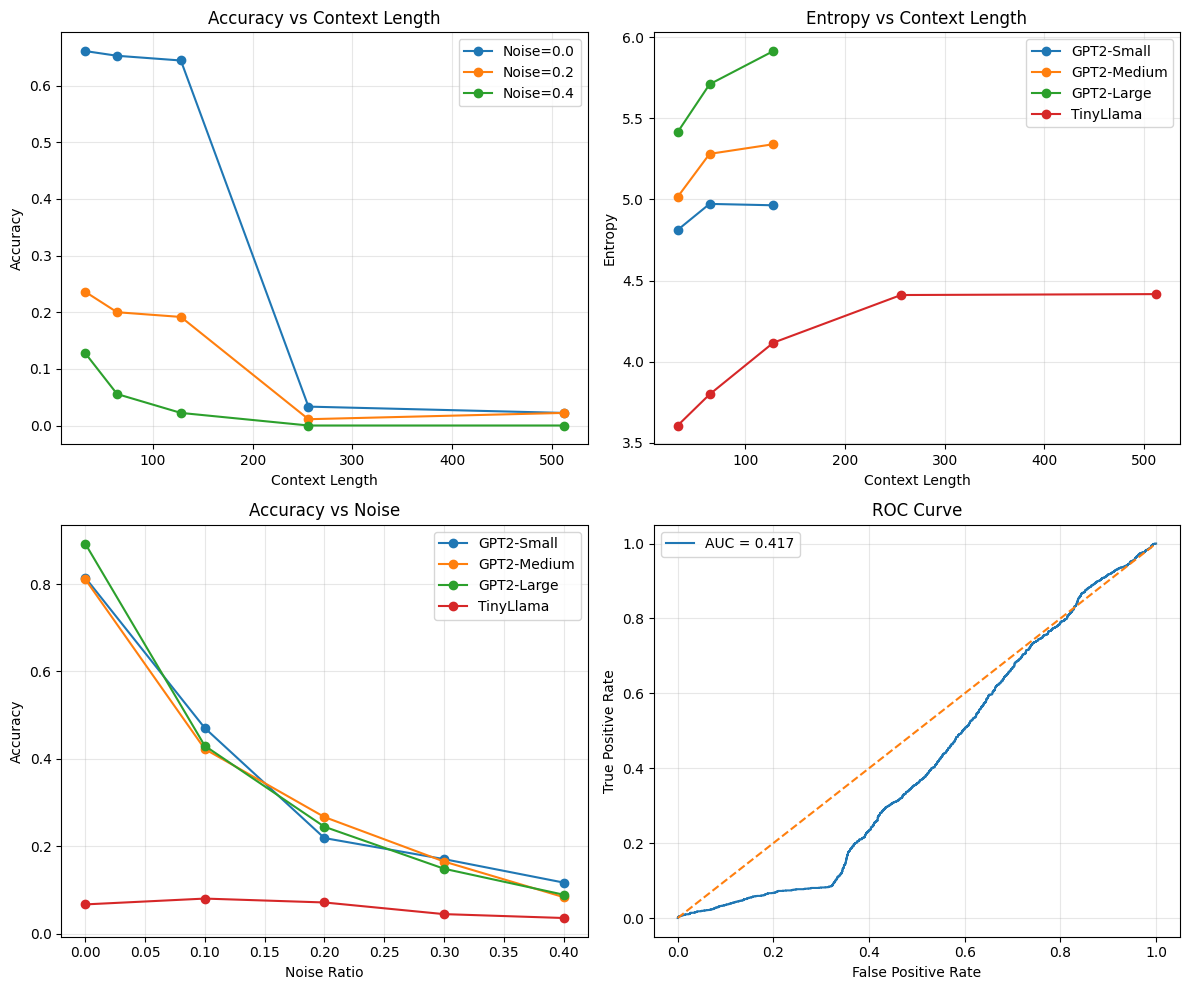

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# -----------------------------
# (a) Accuracy vs Context Length
# -----------------------------

for noise in [0.0, 0.2, 0.4]:

    subset = df[df["noise_ratio"] == noise]

    means = subset.groupby("context_length")["correct"].mean()

    axes[0, 0].plot(
        means.index,
        means.values,
        marker="o",
        label=f"Noise={noise}"
    )

axes[0, 0].set_title("Accuracy vs Context Length")
axes[0, 0].set_xlabel("Context Length")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# -----------------------------
# (b) Entropy vs Context Length
# -----------------------------

for model in df["model"].unique():

    subset = df[df["model"] == model]

    means = subset.groupby("context_length")["entropy"].mean()

    axes[0, 1].plot(
        means.index,
        means.values,
        marker="o",
        label=model
    )

axes[0, 1].set_title("Entropy vs Context Length")
axes[0, 1].set_xlabel("Context Length")
axes[0, 1].set_ylabel("Entropy")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# -----------------------------
# (c) Accuracy vs Noise
# -----------------------------

for model in df["model"].unique():

    subset = df[df["model"] == model]

    means = subset.groupby("noise_ratio")["correct"].mean()

    axes[1, 0].plot(
        means.index,
        means.values,
        marker="o",
        label=model
    )

axes[1, 0].set_title("Accuracy vs Noise")
axes[1, 0].set_xlabel("Noise Ratio")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# -----------------------------
# (d) ROC Curve
# -----------------------------

axes[1, 1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[1, 1].plot([0, 1], [0, 1], "--")

axes[1, 1].set_title("ROC Curve")
axes[1, 1].set_xlabel("False Positive Rate")
axes[1, 1].set_ylabel("True Positive Rate")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
summary = df.groupby(
    ["model", "noise_ratio"]
).agg({
    "correct": ["mean", "std", "count"],
    "entropy": "mean"
}).round(3)

# Flatten column names
summary.columns = [
    "accuracy_mean",
    "accuracy_std",
    "count",
    "entropy_mean"
]

print("=" * 60)
print("SUMMARY TABLE")
print("=" * 60)

print(summary)

# Save for paper / SOP use
summary.to_csv("summary_table.csv")

print("\nSaved: summary_table.csv")

SUMMARY TABLE
                         accuracy_mean  accuracy_std  count  entropy_mean
model       noise_ratio                                                  
GPT2-Large  0.0                  0.893         0.310    270         5.233
            0.1                  0.430         0.496    270         5.691
            0.2                  0.244         0.431    270         5.813
            0.3                  0.148         0.356    182         5.750
            0.4                  0.089         0.285    180         5.832
GPT2-Medium 0.0                  0.811         0.392    270         4.824
            0.1                  0.422         0.495    270         5.180
            0.2                  0.267         0.443    270         5.330
            0.3                  0.165         0.372    182         5.340
            0.4                  0.083         0.277    180         5.412
GPT2-Small  0.0                  0.815         0.389    270         4.423
            0.1         

In [4]:
summary = df.groupby(
    ["model", "noise_ratio"]
).agg({
    "correct": ["mean", "std", "count"],
    "entropy": "mean"
}).round(3)

# Flatten column names
summary.columns = [
    "accuracy_mean",
    "accuracy_std",
    "count",
    "entropy_mean"
]

print("=" * 60)
print("SUMMARY TABLE")
print("=" * 60)

print(summary)

# Save for paper / SOP use
summary.to_csv("summary_table.csv")

print("\nSaved: summary_table.csv")

SUMMARY TABLE
                         accuracy_mean  accuracy_std  count  entropy_mean
model       noise_ratio                                                  
GPT2-Large  0.0                  0.893         0.310    270         5.233
            0.1                  0.430         0.496    270         5.691
            0.2                  0.244         0.431    270         5.813
            0.3                  0.148         0.356    182         5.750
            0.4                  0.089         0.285    180         5.832
GPT2-Medium 0.0                  0.811         0.392    270         4.824
            0.1                  0.422         0.495    270         5.180
            0.2                  0.267         0.443    270         5.330
            0.3                  0.165         0.372    182         5.340
            0.4                  0.083         0.277    180         5.412
GPT2-Small  0.0                  0.815         0.389    270         4.423
            0.1         